# Ensemble Workshop: Predicting Student Success


We will predict whether a student passes using:

1. **XGBoost** — many small trees that correct earlier mistakes
2. **Random Forest** — many independent trees whose class probabilities are averaged
3. **K-Nearest Neighbours (KNN)** — predicts from similar students
4. **Stacking** — combines all three using **Logistic Regression** as the meta learner

By the end, you should be able to explain not only *how* to code stacking, but also *why* five-fold out-of-fold predictions are needed.


## 0. Setup

Run the next cell once if `xgboost` is not already installed. After installation, restart the kernel if your notebook asks you to.

In [1]:
# Uncomment and run only if XGBoost is missing:
# %pip install xgboost pandas scikit-learn matplotlib

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42

## 1. Load and understand the data

Each row represents one student. The target is `passed`:

- `0` = did not pass
- `1` = passed

The dataset is stored as `student.csv` in the `week-8-ml` folder.

In [3]:
possible_paths = [Path("student.csv"), Path("week-8-ml/student.csv")]
data_path = next((path for path in possible_paths if path.is_file()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find week-8-ml/student.csv. Run from the notebook folder or repository root."
    )

df = pd.read_csv(data_path)
print(f"Loaded {data_path} — {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Loaded student.csv — 1200 rows × 9 columns


,hours_studied_weekly,attendance_pct,previous_exam_score,practice_tests_completed,sleep_hours,tutoring_sessions,assignment_completion_pct,class_participation,passed
0,4.5,79,58,0,7.3,2,63,4,0
1,3.3,73,60,4,8.0,2,70,4,0
2,3.3,79,53,1,6.2,1,57,5,0
3,3.3,65,43,4,7.6,2,65,3,0
4,14.5,88,66,3,5.5,0,71,4,1


In [4]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

class_summary = (
    df["passed"]  # Select the target column as a Series
    .value_counts()  # Count students in each class
    .sort_index()  # Order the labels: 0, then 1
    .rename(index={0: "Did not pass", 1: "Passed"})  # Give the row labels readable names
    .to_frame("students")  # Convert the Series to a DataFrame with a students column
)
# Express each class count as a percentage of all students, rounded to one decimal place.
class_summary["percentage"] = (
    100 * class_summary["students"] / len(df)
).round(1)
display(class_summary)

Missing values: 0
Duplicate rows: 0


,students,percentage
passed,,
Did not pass,624,52.0
Passed,576,48.0


### Why explore correlation with passing?

The correlation plot gives us a first look at which numeric features are associated with passing. Positive values mean higher feature values tend to accompany passing; negative values suggest the opposite. Larger absolute values indicate stronger linear associations.

This helps us form questions about what the models might learn. **Correlation does not imply causation**, and a value near zero does not rule out nonlinear patterns or interactions that trees may capture. Use this plot for exploration, rather than as a rule for selecting features from the full dataset.


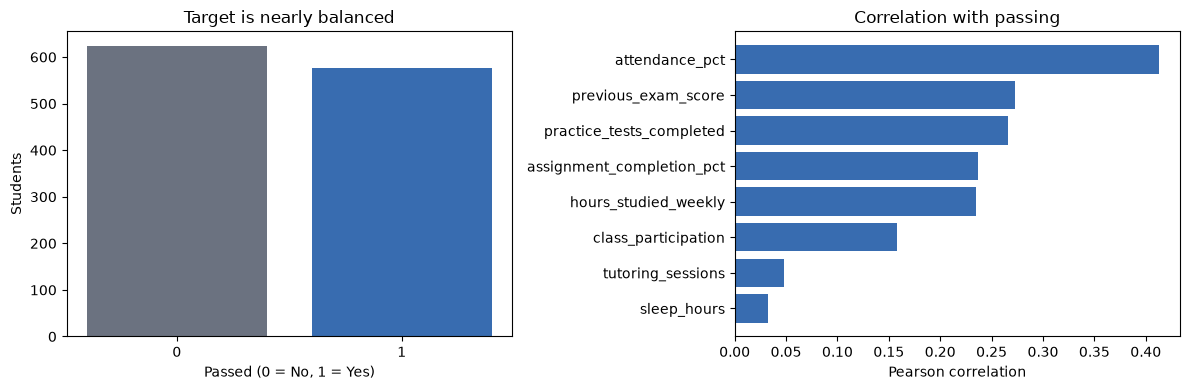

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pass_counts = df["passed"].value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(pass_counts.index, pass_counts.values, color=["#6b7280", "#386cb0"])
axes[0].set_xticks([0, 1])
axes[0].set_title("Target is nearly balanced")
axes[0].set_xlabel("Passed (0 = No, 1 = Yes)")
axes[0].set_ylabel("Students")

corr = df.corr(numeric_only=True)["passed"].drop("passed").sort_values()
axes[1].barh(corr.index, corr.values, color="#386cb0")
axes[1].set_title("Correlation with passing")
axes[1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

## 2. Prepare a stratified train/test split

We train on 80% of the rows and reserve 20% for a final test. `stratify=y` keeps almost the same pass/fail proportion in both sets.

In [6]:
X = df.drop(columns="passed")
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training pass rate:", round(y_train.mean(), 3))
print("Test pass rate:", round(y_test.mean(), 3))

Training rows: 960
Test rows: 240
Training pass rate: 0.48
Test pass rate: 0.479


Training accuracy: 0.724
Test accuracy:     0.713


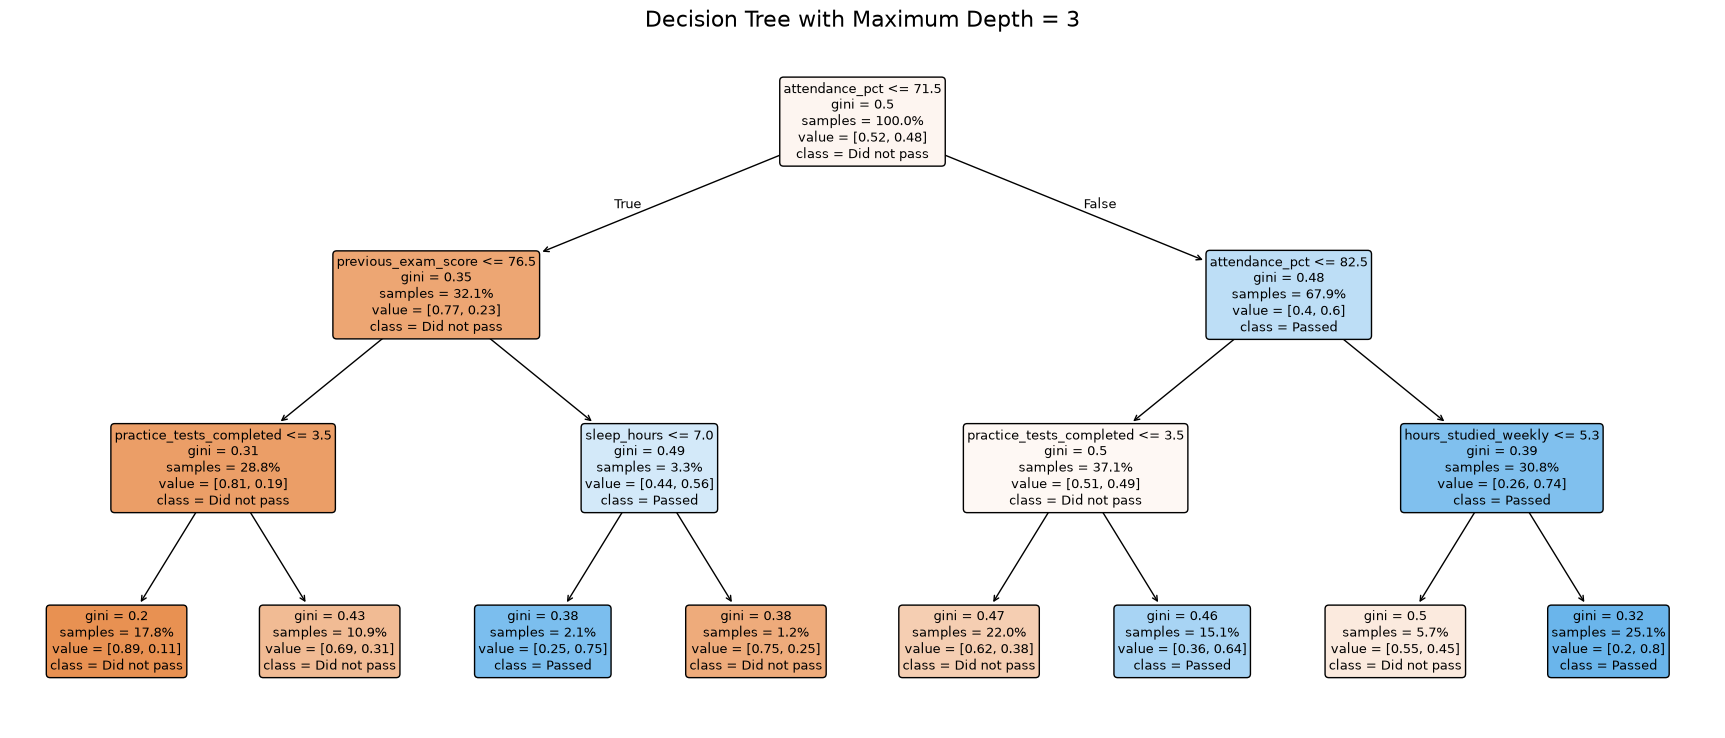

In [7]:
# A small decision tree with a maximum depth of 3
from sklearn.tree import DecisionTreeClassifier, plot_tree

decision_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE,
)

decision_tree.fit(X_train, y_train)

train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Test accuracy:     {test_accuracy:.3f}")

plt.figure(figsize=(22, 9))
plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Did not pass", "Passed"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=9,
)
plt.title("Decision Tree with Maximum Depth = 3", fontsize=16)
plt.show()


## 3. Meet the three base learners

### XGBoost

XGBoost builds trees **sequentially**. Each new tree focuses on mistakes made by the current ensemble. A smaller `learning_rate` makes each new tree contribute less; `n_estimators` controls how many trees are added.

### Random Forest

Random Forest builds many trees **independently** using **bootstrap (sampling with replacement)** samples of the training rows. Each split considers a random subset of features. Randomness helps the trees make different mistakes.

In scikit-learn, the forest **averages the class probabilities** predicted by its trees and chooses the class with the highest average probability; it does not take a hard majority vote of their predicted classes.

> **Tree-based models such as XGBoost and Random Forest do not need feature scaling:** they split on feature thresholds, so differences in feature units do not dominate their decisions.

Reference: [scikit-learn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

### KNN

KNN looks for the `k` most similar training examples. Because distance is sensitive to units, KNN is placed after `StandardScaler`; otherwise a feature ranging from 0–100 could dominate one ranging from 1–5.

In [12]:
xgb_model = XGBClassifier(
    n_estimators=120,          # Number of boosting trees
    max_depth=3,              # Maximum depth of each tree
    learning_rate=0.05,       # Scale each new tree's contribution
    subsample=0.90,           # Use 90% of training rows per boosting round
    colsample_bytree=0.90,    # Use 90% of features for each tree
    objective="binary:logistic",  # Binary classification with probability output
    eval_metric="logloss",   # Log loss metric for evaluation
    random_state=RANDOM_STATE,  # Make random sampling reproducible
    n_jobs=-1,                # Use all available CPU cores
)

rf_model = RandomForestClassifier(
    n_estimators=250,         # Number of trees in the forest
    max_depth=8,              # Maximum depth of each tree
    min_samples_leaf=3,       # Require at least 3 training samples in each leaf
    random_state=RANDOM_STATE,  # Make random sampling reproducible
    n_jobs=-1,                # Use all available CPU cores
)

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=15),
)


In [13]:
def evaluate_model(name, model, X_eval, y_eval):
    predicted_class = model.predict(X_eval)

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, predicted_class),
        "precision": precision_score(y_eval, predicted_class, zero_division=0),
        "recall": recall_score(y_eval, predicted_class, zero_division=0),
        "f1": f1_score(y_eval, predicted_class, zero_division=0),
    }


base_models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
}

base_results = []

for name, model in base_models.items():
    # Fit a fresh clone so the original model configuration can be reused in stacking later.
    fitted_model = clone(model).fit(X_train, y_train)
    base_results.append(evaluate_model(name, fitted_model, X_test, y_test))

base_results_df = pd.DataFrame(base_results).set_index("model")
display(base_results_df.style.format("{:.3f}").highlight_max(axis=0, color="#d8f3dc"))

,accuracy,precision,recall,f1
model,,,,
XGBoost,0.754,0.733,0.765,0.749
Random Forest,0.754,0.741,0.748,0.745
KNN,0.750,0.752,0.713,0.732


**Metric reminder:**

- **Accuracy:** fraction of all predictions that are correct
- **Precision:** among predicted passes, how many truly passed?
- **Recall:** among students who passed, how many did we identify?
- **F1:** balances precision and recall

## 4. Stacking: let another model combine the models

The base learners each output a probability. **The table below is an illustrative example, not predictions or performance measured on the current dataset.**

| Student | XGBoost | Random Forest | KNN | True result |
|---|---:|---:|---:|---:|
| A | 0.90 | 0.82 | 0.73 | 1 |
| B | 0.42 | 0.35 | 0.61 | 0 |

Logistic Regression learns how to combine those three probabilities:

$$P(\text{pass}) = \sigma(b_0 + b_1p_{XGB} + b_2p_{RF} + b_3p_{KNN})$$

where $\sigma$ converts the score into a probability between 0 and 1.

### Why the “5-fold” step matters

If a base model predicts rows that it already trained on, its predictions may look unrealistically good. The meta learner would learn from leaked, overconfident predictions.

Instead, split the training set into five folds:

| Round | Train base models on | Predict |
|---:|---|---|
| 1 | Folds 2–5 | Fold 1 |
| 2 | Folds 1, 3–5 | Fold 2 |
| 3 | Folds 1–2, 4–5 | Fold 3 |
| 4 | Folds 1–3, 5 | Fold 4 |
| 5 | Folds 1–4 | Fold 5 |

After five rounds, **every training student has three predictions from models that did not train on that student**. These are called **out-of-fold predictions**. Logistic Regression learns from this new three-column dataset.

### From OOF training to test predictions

Alongside the five OOF rounds, `StackingClassifier` fits a separate final copy of each base learner on the **whole training set**. The fold-specific models generate the OOF training features; the full-training-set models are retained for prediction. For a test student, these final base learners produce three probabilities, and the Logistic Regression trained on OOF predictions combines them into the final probability.

`passthrough=False` means the meta learner receives **only the base learners' predictions**, without the original student features. For this binary task, scikit-learn keeps one probability per model (`P(passed=1)`), giving the three inputs in our formula. With `passthrough=True`, the original features would also be included.

Reference: [scikit-learn StackingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html).

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

stacking_model = StackingClassifier(
    estimators=[
        ("xgb", clone(xgb_model)),
        ("rf", clone(rf_model)),
        ("knn", clone(knn_model)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv,
    passthrough=False,  # Give the meta learner only model probabilities, without original features
    n_jobs=-1,
)

stacking_model.fit(X_train, y_train)
stacking_result = evaluate_model(
    "Stacking Ensemble", stacking_model, X_test, y_test
)

# Compare all four models on the same held-out test set.
comparison_results_df = pd.concat(
    [base_results_df, pd.DataFrame([stacking_result]).set_index("model")]
)
display(
    comparison_results_df.style.format("{:.3f}")
    .highlight_max(axis=0, color="#d8f3dc")
)

,accuracy,precision,recall,f1
model,,,,
XGBoost,0.754,0.733,0.765,0.749
Random Forest,0.754,0.741,0.748,0.745
KNN,0.750,0.752,0.713,0.732
Stacking Ensemble,0.762,0.742,0.774,0.757


### Inspect the learned stacking weights

The coefficients below correspond to $b_1$, $b_2$, and $b_3$ in the formula, in estimator order: XGBoost, Random Forest, then KNN. The intercept is $b_0$. These weights act on the log-odds score before the sigmoid; they are not percentages and need not sum to one.


In [15]:
# One coefficient per base model's probability, in the estimators list order.
print("Coefficients [b1 (XGBoost), b2 (Random Forest), b3 (KNN)]:")
print(stacking_model.final_estimator_.coef_)
print("Intercept b0:", stacking_model.final_estimator_.intercept_[0])


Coefficients [b1 (XGBoost), b2 (Random Forest), b3 (KNN)]:
[[1.87558776 2.44859522 0.9978862 ]]
Intercept b0: -2.673444892253812
